In [2]:
import pandas as pd

dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 pathway' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)

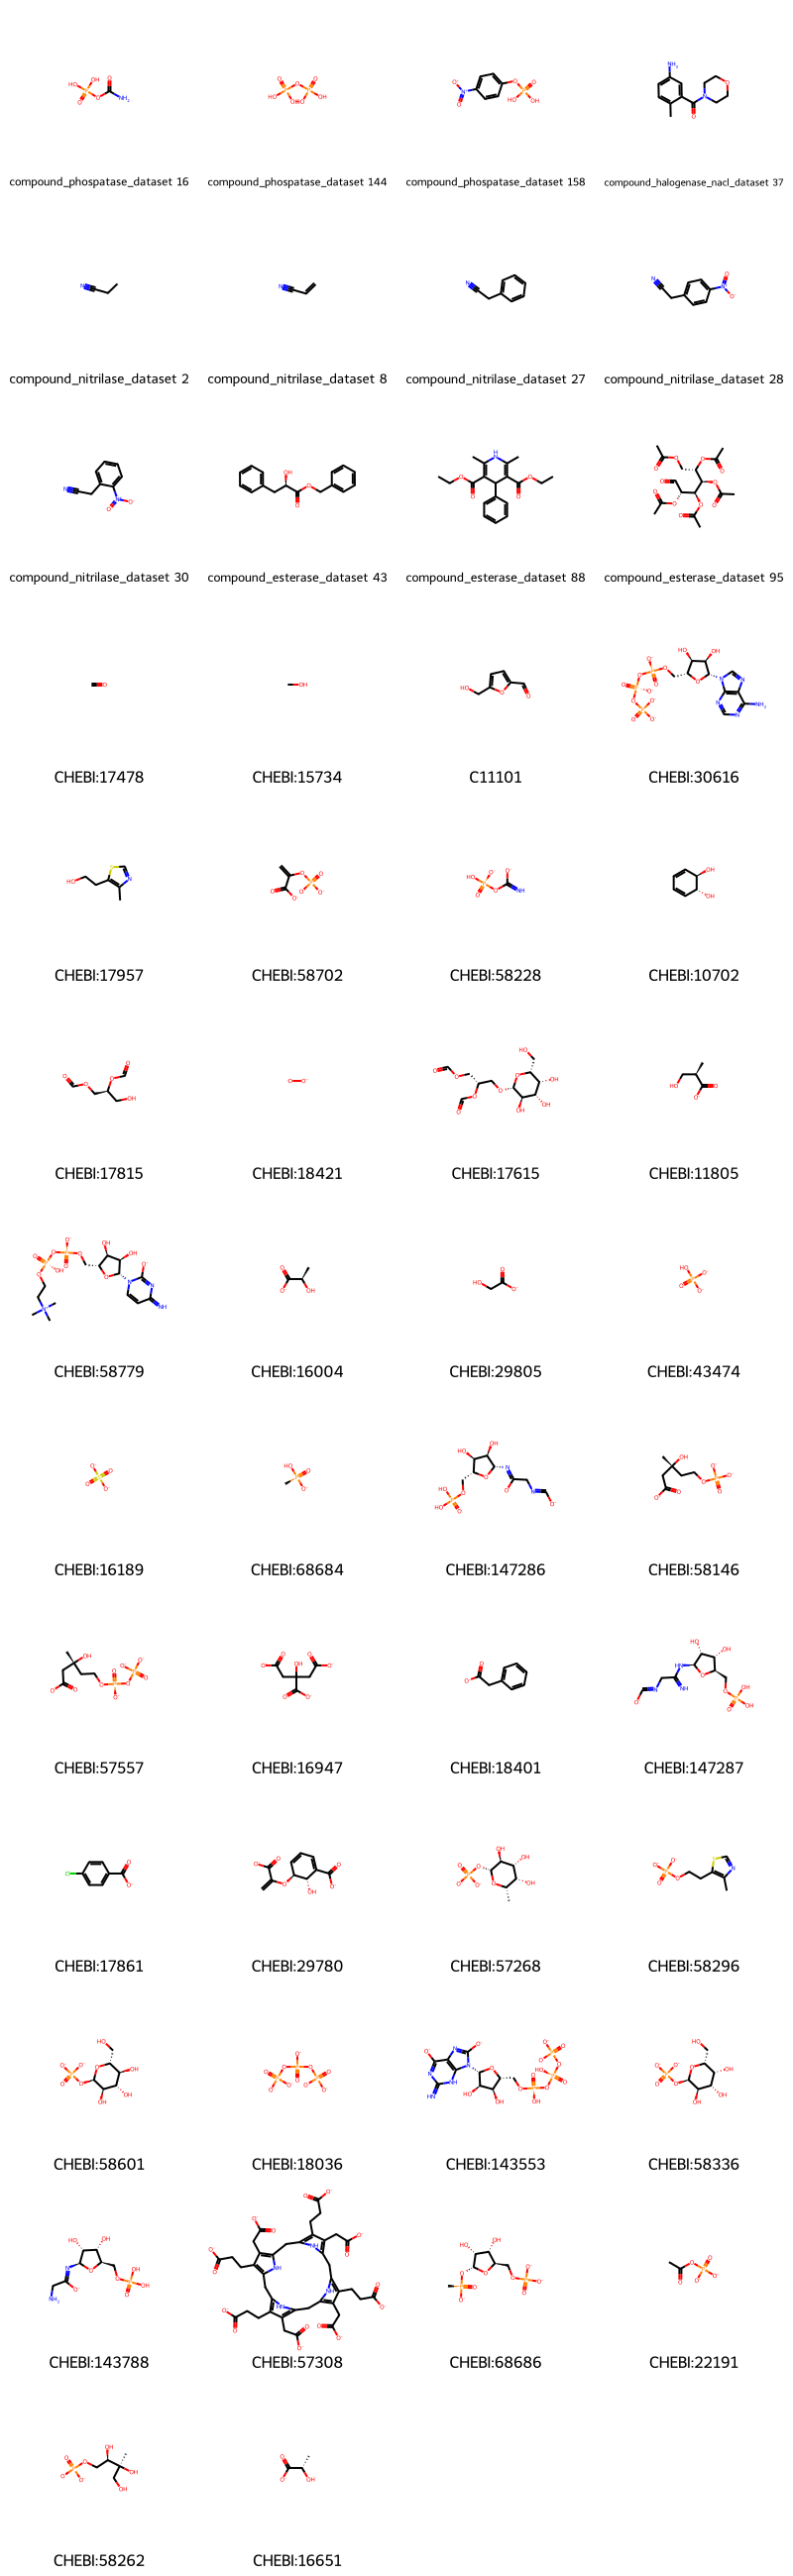

In [5]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# Filter molecules with "NA" pathways
na_molecules = dataset[dataset["Pathways"] == "NA"]

# Function to draw molecules
def draw_molecules(smiles_list, mol_ids):
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=mol_ids)
    return img

# Assuming the dataset has a column named "SMILES" for SMILES strings and "ID" for molecule IDs
smiles_list = na_molecules["SMILES"].tolist()
mol_ids = na_molecules["ID"].tolist()

# Draw the molecules
img = draw_molecules(smiles_list, mol_ids)

# Display the image
img

In [6]:
na_molecules.shape

(133, 5)

In [10]:
dataset["Pathways"]

0              Amino acids and Peptides
1              Amino acids and Peptides
2                                    >1
3                                    >1
4                                    >1
                     ...               
1723    Shikimates and Phenylpropanoids
1724    Shikimates and Phenylpropanoids
1725                          Alkaloids
1726                          Alkaloids
1727    Shikimates and Phenylpropanoids
Name: Pathways, Length: 1728, dtype: object

In [ ]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def generate_tsne_molecular_similarities(dataset, smiles_field):
    # Create a function to compute molecular fingerprints
    def compute_fingerprint(smiles):
        molecule = Chem.MolFromSmiles(smiles)
        fingerprint = AllChem.GetMorganFingerprintAsBitVect(molecule, 2, nBits=1024)
        return fingerprint

    # Compute molecular fingerprints for each molecule in the combined dataset
    fingerprints = [compute_fingerprint(smiles) for smiles in dataset.loc[:, smiles_field]]

    similarity_matrix = np.zeros((len(fingerprints), len(fingerprints)))
    # Compute molecular similarities using Tanimoto coefficient
    for i in range(len(fingerprints)):
        for j in range(i + 1, len(fingerprints)):
            similarity = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity

    # Apply t-SNE to reduce the dimensionality
    tsne = TSNE(n_components=2, random_state=42)
    tsne_embeddings = tsne.fit_transform(similarity_matrix)
    # Separate the embeddings based on the original datasets
    dataset["t-sne 1"] = tsne_embeddings[:, 0]
    dataset["t-sne 2"] = tsne_embeddings[:, 1]

    return dataset

dataset = pd.read_csv("compounds_predicted_pathways.csv")
tsne_ = generate_tsne_molecular_similarities(dataset, "SMILES")


In [4]:
tsne_

,ID,SMILES,Pathways,Superclass,Class,t-sne 1,t-sne 2
0,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,-38.697678,13.515943
1,compound_aminotransferase_dataset 2,C[C@H](N)C(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,-47.748306,13.672454
2,compound_aminotransferase_dataset 3,CC(C)[C@H](N)C(=O)O,"Amino acids and Peptides, Fatty acids","Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids",-47.314949,13.922413
3,compound_aminotransferase_dataset 4,CC(C)C[C@H](N)C(=O)O,"Amino acids and Peptides, Fatty acids","Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids",-51.550209,11.199455
4,compound_aminotransferase_dataset 5,CC[C@H](C)[C@H](N)C(=O)O,"Amino acids and Peptides, Fatty acids","Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids",-49.123417,12.775739
...,...,...,...,...,...,...,...
1723,heptynoate,C#CCCCCC(=O)Oc1ccc([N+](=O)[O-])cc1,Shikimates and Phenylpropanoids,Fatty Acids and Conjugates,NaN,-28.858986,-12.419436
1724,hexanoate,CCCCCC(=O)Oc1ccc([N+](=O)[O-])cc1,Shikimates and Phenylpropanoids,NaN,NaN,-29.954874,-11.052813
1725,oxidazole,O=C(CCc1nnc(-c2ccccc2)o1)Oc1ccc([N+](=O)[O-])cc1,Alkaloids,NaN,NaN,-28.223740,-13.245775
1726,TMA,CC(C)(C)C(=O)Oc1ccc([N+](=O)[O-])cc1,Alkaloids,NaN,NaN,-28.614882,-13.292257


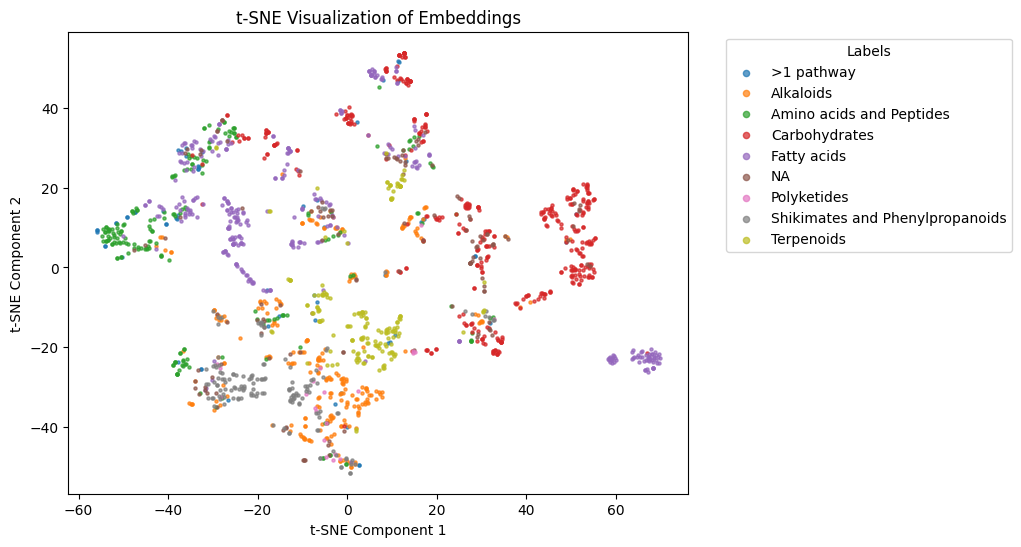

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(dataset.Pathways)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(dataset.Pathways) == str(label))[0]
    plt.scatter(tsne_.loc[idx, "t-sne 1"], tsne_.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [18]:
def generate_tsne_np_classifier(dataset, features):
    features_array = []
    for i, row in dataset.iterrows():
        id_ = row["ID"]
        features_array.append(features[id_])
    features_array = np.array(features_array)
    tsne = TSNE(n_components=2, random_state=42)
    tsne_embeddings = tsne.fit_transform(features_array)
    dataset["t-sne 1"] = tsne_embeddings[:, 0]
    dataset["t-sne 2"] = tsne_embeddings[:, 1]
    return dataset

from plants_sm.io.pickle import read_pickle
dataset = pd.read_csv("compounds_predicted_pathways.csv")
np_classifier_features = read_pickle("../dataset_integration/features_compounds_np_classifier_fp/features.pkl")["ligands"]

tsne_ = generate_tsne_np_classifier(dataset, np_classifier_features)

In [20]:
import pandas as pd

dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 pathway' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)

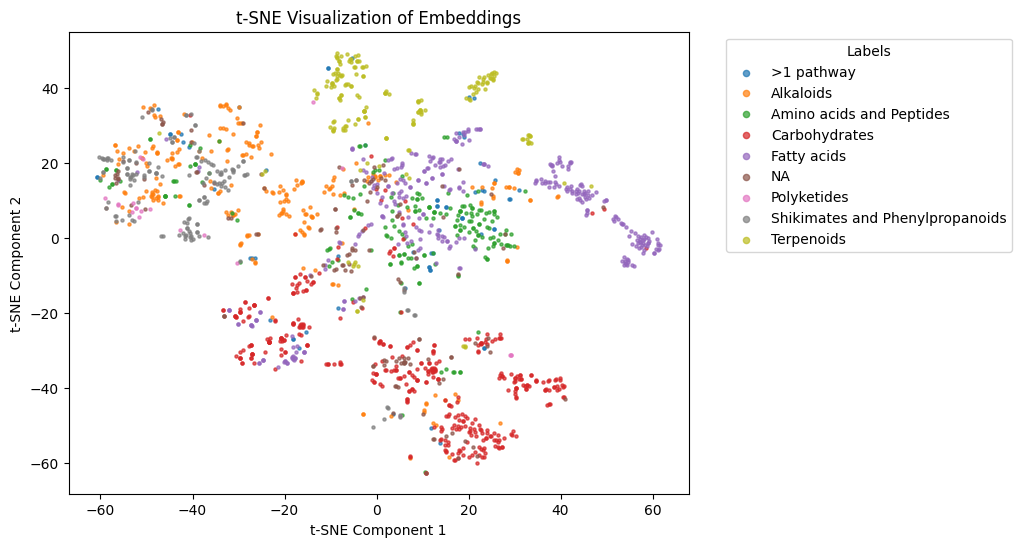

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(dataset.Pathways)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(dataset.Pathways) == str(label))[0]
    plt.scatter(tsne_.loc[idx, "t-sne 1"], tsne_.loc[idx, "t-sne 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [47]:
import os
from deepmol.loaders import CSVLoader
from deepmol.datasets import SmilesDataset
from deepmol.compound_featurization import ThreeDimensionalMoleculeGenerator

# Processing parameters
timeout = 200
threads = 50
n_conformations = 5
max_iterations = 100
etkdg_version = 3
mode = "MMFF94"

dataset = SmilesDataset(smiles=["C[C@@]12CC[C@@]3(C(=CC[C@H]4[C@]3(CC[C@@H]5[C@@]4(CC[C@@H](C5(C)C)O)C)C)[C@@H]1CC(CC2)(C)C)C"])
            
# Generate 3D conformers
generator = ThreeDimensionalMoleculeGenerator(
    timeout_per_molecule=timeout, threads=threads,
    n_conformations=n_conformations, max_iterations=max_iterations
)
generator.generate(dataset, etkdg_version=etkdg_version, mode=mode)

Generating 3D structure: 100%|██████████| 1/1 [00:02<00:00,  2.85s/it]


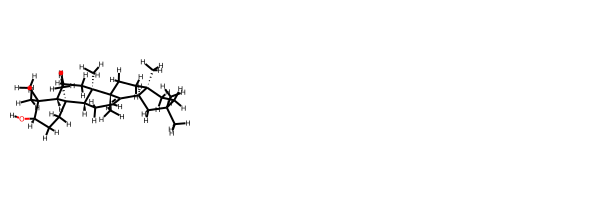

In [35]:
from rdkit.Chem import Draw
Draw.MolsToGridImage(dataset.mols)

In [48]:
import py3Dmol

# Align conformers to the first conformer
rmslist = []
molecule = dataset.mols[0]
AllChem.AlignMolConformers(molecule, RMSlist=rmslist, confIds=[i for i in range(molecule.GetNumConformers())])
# Remove hydrogens from the molecule
molecule = Chem.RemoveHs(molecule)

# Prepare the 3D view
view = py3Dmol.view(width=800, height=400)

# Add each conformer to the view
for confId in range(molecule.GetNumConformers()):
    mb = Chem.MolToMolBlock(molecule, confId=confId)
    view.addModel(mb, 'sdf')

# Set style and other visualization options
view.setStyle({'stick': {}})
view.zoomTo()
# Show the 3D view
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

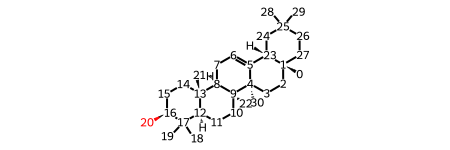

In [46]:
dataset = SmilesDataset(smiles=["C[C@@]12CC[C@@]3(C(=CC[C@H]4[C@]3(CC[C@@H]5[C@@]4(CC[C@@H](C5(C)C)O)C)C)[C@@H]1CC(CC2)(C)C)C"])
# Number the atoms
# Step 2: Add atom numbers
for atom in dataset.mols[0].GetAtoms():
    atom.SetProp('atomLabel', str(atom.GetIdx()))

dataset.mols[0]

In [1]:
from deepmol.datasets import SmilesDataset
import pandas as pd

ids = pd.read_csv("compounds_predicted_pathways.csv")["ID"].tolist()
smiles = pd.read_csv("compounds_predicted_pathways.csv")["SMILES"].tolist()


dataset = SmilesDataset(ids=ids, smiles=smiles)

In [9]:
from deepmol.compound_featurization import MorganFingerprint, NPClassifierFP

NPClassifierFP().featurize(dataset, inplace=True)

NPClassifierFP: 100%|██████████| 1728/1728 [00:02<00:00, 853.92it/s]


In [14]:
import numpy as np

dataset.to_dataframe().iloc[:, 2:]

,npclassifier_0,npclassifier_1,npclassifier_2,npclassifier_3,npclassifier_4,npclassifier_5,npclassifier_6,npclassifier_7,npclassifier_8,npclassifier_9,...,npclassifier_6134,npclassifier_6135,npclassifier_6136,npclassifier_6137,npclassifier_6138,npclassifier_6139,npclassifier_6140,npclassifier_6141,npclassifier_6142,npclassifier_6143
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1725,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1726,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
